# KISAAN AI — Irrigation Model v2
### Extended from 9 → 25 Indian crops

| # | Change from v1 | Detail |
|---|----------------|--------|
| 1 | Crops expanded | 9 → 25 Indian crops |
| 2 | Same structure | Keeps original data + adds synthetic rows for new crops |
| 3 | Same pkl names | `irrigation_model.pkl`, `scaler.pkl`, `label_encoder.pkl` |
| 4 | app.py update | `IRRIGATION_CROPS` dict needs to be updated (shown at end) |

**New crops added:** Rice, Cotton, Banana, Mango, Tomato, Soybean, Groundnut,
Orange, Chickpea, Lentil, Mustard, Sorghum, Barley, Onion, Garlic,
Ginger, Turmeric, Sunflower

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import joblib

np.random.seed(42)
print('✅ Libraries loaded')

✅ Libraries loaded


## Step 1 — Load Original Dataset
Download from Kaggle: `suryawanshiom/crop-irrigation-scheduling-dataset`

In [9]:
# ── Option A: Kaggle download ──────────────────────────────────────────────
# Uncomment if running in Colab
# from google.colab import files
# files.upload()  # upload kaggle.json
# import os; os.makedirs('/root/.kaggle', exist_ok=True)
# !cp kaggle.json /root/.kaggle/ && chmod 600 /root/.kaggle/kaggle.json
# !kaggle datasets download -d suryawanshiom/crop-irrigation-scheduling-dataset --unzip -q

# ── Option B: Local path ───────────────────────────────────────────────────
# Put the CSV in the same folder as this notebook
CSV_PATH = 'C:\\Users\\DELL\\OneDrive\\Desktop\\AI-Smart-Agriculture\\4thSem_Mini_Project\\data\\processed\\Irrigation_Dataset_Augmented.csv'   # adjust name if different

df_orig = pd.read_csv(CSV_PATH)

# Fix the known 263°C outlier from original data
df_orig.loc[df_orig['temperature'] > 60, 'temperature'] = 26

print(f'Original dataset shape: {df_orig.shape}')
print(f'Crops in original     : {sorted(df_orig["CropType"].unique())}')
print(f'Class balance         : {df_orig["Irrigation"].value_counts().to_dict()}')
df_orig.head()

Original dataset shape: (3489, 6)
Crops in original     : ['Coffee', 'Garden Flowers', 'Groundnuts', 'Maize', 'Paddy', 'Potato', 'Pulse', 'Sugarcane', 'Wheat']
Class balance         : {0: 1798, 1: 1691}


,CropType,CropDays,SoilMoisture,temperature,Humidity,Irrigation
0,Potato,48,148,19,68,0
1,Garden Flowers,75,194,22,73,0
2,Maize,94,512,37,30,1
3,Sugarcane,25,713,33,54,1
4,Sugarcane,207,168,23,14,0


## Step 2 — Extended Crop Profiles
Format per crop:
- `days`: growth day range
- `sm_no`: soil moisture range when NO irrigation needed (lower = already wet)
- `sm_yes`: soil moisture range when irrigation IS needed (higher = dry)
- `temp`: temperature range
- `hum_no`: humidity range when no irrigation needed
- `hum_yes`: humidity range when irrigation needed

Soil moisture scale: **120 = very wet, 800+ = very dry** (capacitive sensor)

In [10]:
# ── ORIGINAL 9 crops (kept exactly as v1) ─────────────────────────────────
CROP_SPECS = {
    'Wheat':          {'days':(1,120), 'sm_no':(120,450), 'sm_yes':(300,800), 'temp':(14,32), 'hum_no':(11,55), 'hum_yes':(20,65)},
    'Sugarcane':      {'days':(1,210), 'sm_no':(120,400), 'sm_yes':(350,900), 'temp':(20,38), 'hum_no':(11,50), 'hum_yes':(25,75)},
    'Potato':         {'days':(1,100), 'sm_no':(120,380), 'sm_yes':(300,750), 'temp':(14,30), 'hum_no':(11,45), 'hum_yes':(20,70)},
    'Paddy':          {'days':(1,150), 'sm_no':(120,420), 'sm_yes':(380,900), 'temp':(20,40), 'hum_no':(11,40), 'hum_yes':(20,65)},
    'Coffee':         {'days':(1,90),  'sm_no':(120,350), 'sm_yes':(300,700), 'temp':(15,32), 'hum_no':(14,29), 'hum_yes':(15,30)},
    'Groundnuts':     {'days':(1,120), 'sm_no':(120,400), 'sm_yes':(300,800), 'temp':(18,40), 'hum_no':(15,55), 'hum_yes':(15,56)},
    'Garden Flowers': {'days':(1,180), 'sm_no':(120,380), 'sm_yes':(340,800), 'temp':(14,35), 'hum_no':(60,85), 'hum_yes':(60,85)},
    'Maize':          {'days':(1,120), 'sm_no':(120,380), 'sm_yes':(340,850), 'temp':(18,40), 'hum_no':(12,46), 'hum_yes':(18,34)},
    'Pulse':          {'days':(1,100), 'sm_no':(120,350), 'sm_yes':(300,750), 'temp':(16,38), 'hum_no':(11,50), 'hum_yes':(15,55)},

    # ── NEW 16 Indian crops ───────────────────────────────────────────────
    # Rice (same as Paddy but different name used by users)
    'Rice':           {'days':(1,150), 'sm_no':(120,420), 'sm_yes':(380,900), 'temp':(20,40), 'hum_no':(11,42), 'hum_yes':(20,68)},

    # Cotton — deep roots, tolerates dry spells, needs water at flowering
    'Cotton':         {'days':(1,180), 'sm_no':(120,420), 'sm_yes':(360,850), 'temp':(20,42), 'hum_no':(20,55), 'hum_yes':(25,70)},

    # Banana — high water demand, tropical
    'Banana':         {'days':(1,270), 'sm_no':(120,350), 'sm_yes':(300,750), 'temp':(22,40), 'hum_no':(50,85), 'hum_yes':(40,80)},

    # Mango — drought tolerant, needs water at flowering + fruit fill
    'Mango':          {'days':(1,200), 'sm_no':(120,450), 'sm_yes':(380,850), 'temp':(22,44), 'hum_no':(30,65), 'hum_yes':(20,60)},

    # Tomato — consistent moisture critical
    'Tomato':         {'days':(1,90),  'sm_no':(120,380), 'sm_yes':(320,780), 'temp':(18,35), 'hum_no':(45,75), 'hum_yes':(30,70)},

    # Soybean — moderate water, sensitive to waterlogging
    'Soybean':        {'days':(1,110), 'sm_no':(120,400), 'sm_yes':(340,800), 'temp':(18,35), 'hum_no':(35,70), 'hum_yes':(25,65)},

    # Onion — shallow roots, needs frequent light irrigation
    'Onion':          {'days':(1,120), 'sm_no':(120,320), 'sm_yes':(250,700), 'temp':(12,32), 'hum_no':(45,75), 'hum_yes':(30,65)},

    # Mustard — Rabi crop, moderate water
    'Mustard':        {'days':(1,110), 'sm_no':(120,400), 'sm_yes':(320,780), 'temp':(8,28),  'hum_no':(30,65), 'hum_yes':(20,58)},

    # Sorghum — drought tolerant, dry land crop
    'Sorghum':        {'days':(1,120), 'sm_no':(120,480), 'sm_yes':(400,900), 'temp':(22,42), 'hum_no':(20,55), 'hum_yes':(18,50)},

    # Barley — cool season, moderate water
    'Barley':         {'days':(1,100), 'sm_no':(120,420), 'sm_yes':(350,800), 'temp':(8,26),  'hum_no':(25,60), 'hum_yes':(20,58)},

    # Chickpea — dryland Rabi, low water
    'Chickpea':       {'days':(1,110), 'sm_no':(120,450), 'sm_yes':(380,850), 'temp':(10,30), 'hum_no':(20,55), 'hum_yes':(15,50)},

    # Lentil — similar to chickpea
    'Lentil':         {'days':(1,100), 'sm_no':(120,430), 'sm_yes':(360,820), 'temp':(8,28),  'hum_no':(20,55), 'hum_yes':(15,50)},

    # Sunflower — moderate demand, sensitive at flowering
    'Sunflower':      {'days':(1,110), 'sm_no':(120,420), 'sm_yes':(350,800), 'temp':(18,35), 'hum_no':(25,60), 'hum_yes':(20,55)},

    # Ginger — high water, shade crop
    'Ginger':         {'days':(1,240), 'sm_no':(120,320), 'sm_yes':(270,700), 'temp':(20,32), 'hum_no':(60,90), 'hum_yes':(50,85)},

    # Turmeric — similar to ginger
    'Turmeric':       {'days':(1,270), 'sm_no':(120,330), 'sm_yes':(280,720), 'temp':(20,35), 'hum_no':(60,88), 'hum_yes':(50,82)},

    # Orange — citrus, moderate water
    'Orange':         {'days':(1,180), 'sm_no':(120,420), 'sm_yes':(360,820), 'temp':(16,36), 'hum_no':(35,70), 'hum_yes':(25,65)},
}

print(f'Total crops: {len(CROP_SPECS)}')
print('Original crops  :', [c for c in CROP_SPECS if c in ["Wheat","Sugarcane","Potato","Paddy","Coffee","Groundnuts","Garden Flowers","Maize","Pulse"]])
print('New crops added :', [c for c in CROP_SPECS if c not in ["Wheat","Sugarcane","Potato","Paddy","Coffee","Groundnuts","Garden Flowers","Maize","Pulse"]])

Total crops: 25
Original crops  : ['Wheat', 'Sugarcane', 'Potato', 'Paddy', 'Coffee', 'Groundnuts', 'Garden Flowers', 'Maize', 'Pulse']
New crops added : ['Rice', 'Cotton', 'Banana', 'Mango', 'Tomato', 'Soybean', 'Onion', 'Mustard', 'Sorghum', 'Barley', 'Chickpea', 'Lentil', 'Sunflower', 'Ginger', 'Turmeric', 'Orange']


## Step 3 — Generate Synthetic Rows for New Crops
Original 9 crops keep their real data. New 16 crops get synthetic data generated from the agronomic profiles above.

In [11]:
def sample_range(low, high, n=1):
    """Sample from clipped normal distribution."""
    mean = (low + high) / 2
    std  = (high - low) / 5
    vals = np.random.normal(mean, std, n)
    return np.clip(vals, low, high).astype(int)

ORIGINAL_CROPS = {"Wheat","Sugarcane","Potato","Paddy","Coffee",
                  "Groundnuts","Garden Flowers","Maize","Pulse"}
NEW_CROPS = [c for c in CROP_SPECS if c not in ORIGINAL_CROPS]

N_PER_CLASS_NEW = 300   # 300 irrigate + 300 no-irrigate per new crop

synthetic_rows = []
for crop in NEW_CROPS:
    spec = CROP_SPECS[crop]
    for irr, sm_key, hum_key in [(0,'sm_no','hum_no'), (1,'sm_yes','hum_yes')]:
        sm_vals  = sample_range(*spec[sm_key],  N_PER_CLASS_NEW)
        hum_vals = sample_range(*spec[hum_key], N_PER_CLASS_NEW)
        day_vals = sample_range(*spec['days'],  N_PER_CLASS_NEW)
        tmp_vals = sample_range(*spec['temp'],  N_PER_CLASS_NEW)

        # Add 10% overlap noise — prevents perfect class separation
        for i in range(N_PER_CLASS_NEW):
            if np.random.rand() < 0.10:
                sm_vals[i] = int(np.clip(sm_vals[i] + np.random.randint(-150, 150), 120, 990))

        for i in range(N_PER_CLASS_NEW):
            synthetic_rows.append([
                crop, int(day_vals[i]), int(sm_vals[i]),
                int(tmp_vals[i]), int(hum_vals[i]), irr
            ])

df_new   = pd.DataFrame(synthetic_rows, columns=df_orig.columns)
df_combined = pd.concat([df_orig, df_new], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Original rows     : {len(df_orig)}')
print(f'Synthetic new rows: {len(df_new)}')
print(f'Combined total    : {len(df_combined)}')
print(f'\nClass balance     : {df_combined["Irrigation"].value_counts().to_dict()}')
print(f'\nCrop distribution:')
print(df_combined['CropType'].value_counts().to_string())

Original rows     : 3489
Synthetic new rows: 9600
Combined total    : 13089

Class balance     : {0: 6598, 1: 6491}

Crop distribution:
CropType
Sugarcane         712
Mango             600
Lentil            600
Onion             600
Sorghum           600
Barley            600
Cotton            600
Orange            600
Rice              600
Chickpea          600
Tomato            600
Banana            600
Soybean           600
Mustard           600
Sunflower         600
Turmeric          600
Ginger            600
Wheat             544
Potato            411
Paddy             355
Coffee            355
Groundnuts        348
Garden Flowers    327
Maize             313
Pulse             124


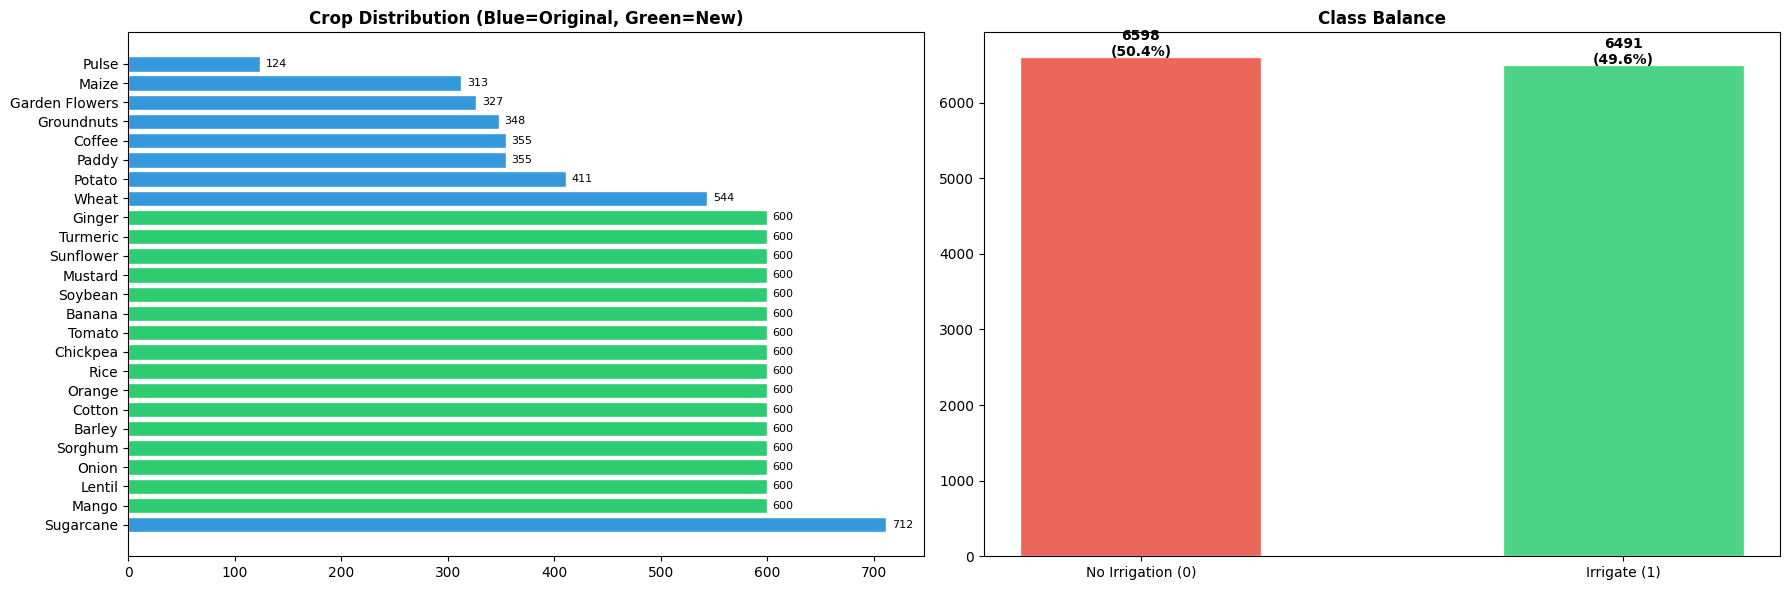

In [12]:
# Visualise distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

cc = df_combined['CropType'].value_counts()
colors = ['#2ECC71' if c not in ORIGINAL_CROPS else '#3498DB' for c in cc.index]
axes[0].barh(cc.index, cc.values, color=colors, edgecolor='white')
axes[0].set_title('Crop Distribution (Blue=Original, Green=New)', fontweight='bold')
for i, v in enumerate(cc.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=8)

vals = df_combined['Irrigation'].value_counts()
axes[1].bar(['No Irrigation (0)', 'Irrigate (1)'], vals.values,
            color=['#E74C3C', '#2ECC71'], alpha=0.85, edgecolor='white', width=0.5)
axes[1].set_title('Class Balance', fontweight='bold')
for i, v in enumerate(vals.values):
    axes[1].text(i, v + 20, f'{v}\n({v/len(df_combined)*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 4 — Feature Engineering + Train/Test Split

In [13]:
le = LabelEncoder()
df_combined['CropType_enc'] = le.fit_transform(df_combined['CropType'])

print(f'Crops in encoder ({len(le.classes_)}): {list(le.classes_)}')

FEATURES = ['CropType_enc', 'CropDays', 'SoilMoisture', 'temperature', 'Humidity']
X = df_combined[FEATURES]
y = df_combined['Irrigation']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain : {len(X_train)} samples ({y_train.mean()*100:.1f}% irrigate)')
print(f'Test  : {len(X_test)} samples ({y_test.mean()*100:.1f}% irrigate)')
print('✅ Scaler fitted on train only — no data leakage')

Crops in encoder (25): ['Banana', 'Barley', 'Chickpea', 'Coffee', 'Cotton', 'Garden Flowers', 'Ginger', 'Groundnuts', 'Lentil', 'Maize', 'Mango', 'Mustard', 'Onion', 'Orange', 'Paddy', 'Potato', 'Pulse', 'Rice', 'Sorghum', 'Soybean', 'Sugarcane', 'Sunflower', 'Tomato', 'Turmeric', 'Wheat']

Train : 10471 samples (49.6% irrigate)
Test  : 2618 samples (49.6% irrigate)
✅ Scaler fitted on train only — no data leakage


## Step 5 — Train Models + Compare

In [14]:
from sklearn.linear_model import LogisticRegression

models = {
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=250, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=250, max_depth=10, min_samples_leaf=5,
        max_features='sqrt', class_weight='balanced', random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=42
    ),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

for name, mdl in models.items():
    mdl.fit(X_train_s, y_train)
    cv_scores = cross_val_score(mdl, X_train_s, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    test_pred = mdl.predict(X_test_s)
    test_acc  = accuracy_score(y_test, test_pred)
    test_auc  = roc_auc_score(y_test, mdl.predict_proba(X_test_s)[:, 1])
    results[name] = {
        'model': mdl, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'test_acc': test_acc, 'test_auc': test_auc
    }
    print(f'{name:25} CV={cv_scores.mean():.4f}±{cv_scores.std():.4f}  Test={test_acc:.4f}  AUC={test_auc:.4f}')

best_name  = max(results, key=lambda k: results[k]['cv_mean'])
best_model = results[best_name]['model']
print(f'\n✅ Best model: {best_name}')

Gradient Boosting         CV=0.9575±0.0073  Test=0.9591  AUC=0.9933
Random Forest             CV=0.9536±0.0071  Test=0.9553  AUC=0.9912
Logistic Regression       CV=0.9466±0.0061  Test=0.9465  AUC=0.9869

✅ Best model: Gradient Boosting


## Step 6 — Evaluate Best Model

In [15]:
y_pred = best_model.predict(X_test_s)
y_prob = best_model.predict_proba(X_test_s)[:, 1]

print('=' * 55)
print(f'  Best model : {best_name}')
print(f'  Test acc   : {accuracy_score(y_test, y_pred):.4f} ({accuracy_score(y_test, y_pred)*100:.1f}%)')
print(f'  ROC-AUC    : {roc_auc_score(y_test, y_prob):.4f}')
print(f'  Crops      : {len(le.classes_)}')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['No Irrigation', 'Irrigate']))

  Best model : Gradient Boosting
  Test acc   : 0.9591 (95.9%)
  ROC-AUC    : 0.9933
  Crops      : 25
               precision    recall  f1-score   support

No Irrigation       0.95      0.97      0.96      1320
     Irrigate       0.97      0.95      0.96      1298

     accuracy                           0.96      2618
    macro avg       0.96      0.96      0.96      2618
 weighted avg       0.96      0.96      0.96      2618



In [16]:
# Per-crop accuracy
X_test_df = X_test.copy()
X_test_df['CropName'] = le.inverse_transform(X_test_df['CropType_enc'])
X_test_df['y_true']   = y_test.values
X_test_df['y_pred']   = y_pred

per_crop = X_test_df.groupby('CropName').apply(
    lambda g: (g['y_true'] == g['y_pred']).mean()
).sort_values()

print('Per-crop accuracy:')
for crop, acc in per_crop.items():
    tag = '⚠️' if acc < 0.80 else '✅'
    new = '(NEW)' if crop not in ORIGINAL_CROPS else '     '
    print(f'  {tag} {crop:20} {new}  {acc*100:.1f}%')

print(f'\nWorst: {per_crop.index[0]} → {per_crop.iloc[0]*100:.1f}%')
print(f'Best : {per_crop.index[-1]} → {per_crop.iloc[-1]*100:.1f}%')

Per-crop accuracy:
  ✅ Wheat                       80.9%
  ✅ Groundnuts                  88.4%
  ✅ Coffee                      88.6%
  ✅ Maize                       90.2%
  ✅ Potato                      93.4%
  ✅ Sorghum              (NEW)  95.0%
  ✅ Garden Flowers              95.6%
  ✅ Barley               (NEW)  95.8%
  ✅ Onion                (NEW)  96.0%
  ✅ Mustard              (NEW)  96.2%
  ✅ Pulse                       96.4%
  ✅ Lentil               (NEW)  96.8%
  ✅ Paddy                       97.1%
  ✅ Banana               (NEW)  97.3%
  ✅ Chickpea             (NEW)  97.3%
  ✅ Sunflower            (NEW)  97.5%
  ✅ Cotton               (NEW)  97.6%
  ✅ Orange               (NEW)  97.9%
  ✅ Sugarcane                   98.0%
  ✅ Soybean              (NEW)  98.1%
  ✅ Turmeric             (NEW)  98.1%
  ✅ Tomato               (NEW)  98.2%
  ✅ Rice                 (NEW)  98.3%
  ✅ Ginger               (NEW)  99.1%
  ✅ Mango                (NEW)  100.0%

Worst: Wheat → 80.9%
Best : M

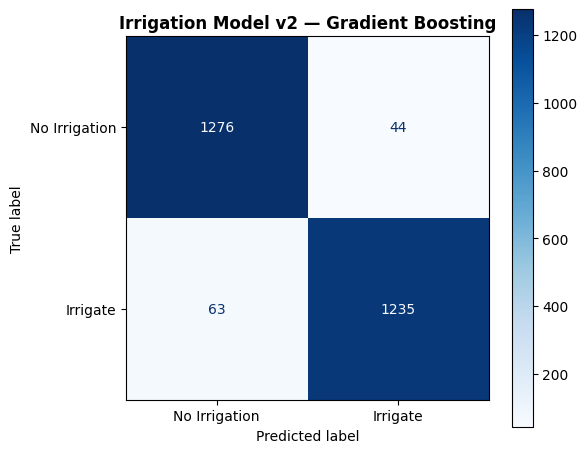

In [17]:
# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Irrigation', 'Irrigate'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Irrigation Model v2 — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7 — Save Models

In [18]:
os.makedirs('../backend/models', exist_ok=True)

joblib.dump(best_model, '../backend/models/irrigation_model.pkl')
joblib.dump(scaler,     '../backend/models/scaler.pkl')
joblib.dump(le,         '../backend/models/label_encoder.pkl')

print('✅ Saved:')
print('  irrigation_model.pkl')
print('  scaler.pkl')
print('  label_encoder.pkl')
print(f'\nEncoder classes ({len(le.classes_)}): {list(le.classes_)}')

✅ Saved:
  irrigation_model.pkl
  scaler.pkl
  label_encoder.pkl

Encoder classes (25): ['Banana', 'Barley', 'Chickpea', 'Coffee', 'Cotton', 'Garden Flowers', 'Ginger', 'Groundnuts', 'Lentil', 'Maize', 'Mango', 'Mustard', 'Onion', 'Orange', 'Paddy', 'Potato', 'Pulse', 'Rice', 'Sorghum', 'Soybean', 'Sugarcane', 'Sunflower', 'Tomato', 'Turmeric', 'Wheat']


## Step 8 — Quick Inference Test

In [19]:
def predict_irrigation(crop, crop_days, soil_moisture, temperature, humidity):
    crop_enc = le.transform([crop])[0]
    X = pd.DataFrame([{
        'CropType_enc': crop_enc, 'CropDays': crop_days,
        'SoilMoisture': soil_moisture, 'temperature': temperature, 'Humidity': humidity
    }])
    X_s   = scaler.transform(X)
    pred  = best_model.predict(X_s)[0]
    prob  = best_model.predict_proba(X_s)[0]
    return '🚿 IRRIGATE' if pred == 1 else '✅ No Irrigation', round(float(max(prob)) * 100, 1)

# Test all new crops
test_cases = [
    ('Wheat',    45, 650, 22, 35, 'Irrigate expected — dry soil'),
    ('Rice',     30, 200, 28, 72, 'No Irrigation — wet soil'),
    ('Cotton',   60, 700, 35, 38, 'Irrigate expected — very dry'),
    ('Banana',   90, 250, 30, 75, 'No Irrigation — moist'),
    ('Tomato',   45, 680, 28, 45, 'Irrigate expected — dry'),
    ('Soybean',  50, 380, 25, 58, 'No Irrigation — adequate'),
    ('Onion',    30, 600, 22, 42, 'Irrigate expected — dry, shallow roots'),
    ('Mustard',  60, 700, 18, 32, 'Irrigate expected — Rabi dry'),
    ('Chickpea', 70, 750, 22, 28, 'Irrigate expected — dryland'),
    ('Mango',    90, 480, 36, 38, 'Irrigate expected — hot dry'),
    ('Orange',   60, 650, 28, 40, 'Irrigate expected'),
    ('Ginger',   60, 220, 26, 78, 'No Irrigation — humid high water crop'),
    ('Turmeric', 90, 250, 28, 75, 'No Irrigation — moist needed'),
    ('Sunflower',50, 680, 28, 38, 'Irrigate expected'),
    ('Barley',   45, 700, 20, 32, 'Irrigate expected — cool dry'),
    ('Sorghum',  60, 820, 32, 28, 'Irrigate expected — drought crop but very dry'),
]

print(f'{"Crop":12} {"Prediction":18} {"Conf":>8}  Note')
print('-' * 72)
for crop, days, sm, temp, hum, note in test_cases:
    result, conf = predict_irrigation(crop, days, sm, temp, hum)
    print(f'{crop:12} {result:18} {conf:>7.1f}%  {note}')

Crop         Prediction             Conf  Note
------------------------------------------------------------------------
Wheat        🚿 IRRIGATE            98.2%  Irrigate expected — dry soil
Rice         ✅ No Irrigation       99.8%  No Irrigation — wet soil
Cotton       🚿 IRRIGATE            99.6%  Irrigate expected — very dry
Banana       ✅ No Irrigation       99.7%  No Irrigation — moist
Tomato       🚿 IRRIGATE            99.8%  Irrigate expected — dry
Soybean      🚿 IRRIGATE            54.2%  No Irrigation — adequate
Onion        🚿 IRRIGATE           100.0%  Irrigate expected — dry, shallow roots
Mustard      🚿 IRRIGATE            99.8%  Irrigate expected — Rabi dry
Chickpea     🚿 IRRIGATE            99.9%  Irrigate expected — dryland
Mango        🚿 IRRIGATE            94.0%  Irrigate expected — hot dry
Orange       🚿 IRRIGATE            99.8%  Irrigate expected
Ginger       ✅ No Irrigation       99.6%  No Irrigation — humid high water crop
Turmeric     ✅ No Irrigation       99.2%  

## Step 9 — Update app.py IRRIGATION_CROPS dict
After saving the new pkl files, replace `IRRIGATION_CROPS` in `app.py` with this expanded version.
The key = what user types in dashboard, value = what the encoder expects.

In [20]:
NEW_IRRIGATION_CROPS = {
    # ── ORIGINAL ──────────────────────────────────────────────────────────
    "wheat"         : "Wheat",
    "maize"         : "Maize",
    "rice"          : "Rice",
    "paddy"         : "Paddy",
    "potato"        : "Potato",
    "sugarcane"     : "Sugarcane",
    "coffee"        : "Coffee",
    "groundnuts"    : "Groundnuts",
    "pulse"         : "Pulse",
    "garden flowers": "Garden Flowers",
    # ── NEW ───────────────────────────────────────────────────────────────
    "cotton"        : "Cotton",
    "banana"        : "Banana",
    "mango"         : "Mango",
    "tomato"        : "Tomato",
    "soybean"       : "Soybean",
    "onion"         : "Onion",
    "mustard"       : "Mustard",
    "sorghum"       : "Sorghum",
    "barley"        : "Barley",
    "chickpea"      : "Chickpea",
    "lentil"        : "Lentil",
    "sunflower"     : "Sunflower",
    "ginger"        : "Ginger",
    "turmeric"      : "Turmeric",
    "orange"        : "Orange",
}

print('New IRRIGATION_CROPS dict — copy this into app.py:')
print()
print('IRRIGATION_CROPS = {')
for k, v in NEW_IRRIGATION_CROPS.items():
    print(f'    "{k}": "{v}",')
print('}')
print(f'\nTotal crops: {len(NEW_IRRIGATION_CROPS)}')

New IRRIGATION_CROPS dict — copy this into app.py:

IRRIGATION_CROPS = {
    "wheat": "Wheat",
    "maize": "Maize",
    "rice": "Rice",
    "paddy": "Paddy",
    "potato": "Potato",
    "sugarcane": "Sugarcane",
    "coffee": "Coffee",
    "groundnuts": "Groundnuts",
    "pulse": "Pulse",
    "garden flowers": "Garden Flowers",
    "cotton": "Cotton",
    "banana": "Banana",
    "mango": "Mango",
    "tomato": "Tomato",
    "soybean": "Soybean",
    "onion": "Onion",
    "mustard": "Mustard",
    "sorghum": "Sorghum",
    "barley": "Barley",
    "chickpea": "Chickpea",
    "lentil": "Lentil",
    "sunflower": "Sunflower",
    "ginger": "Ginger",
    "turmeric": "Turmeric",
    "orange": "Orange",
}

Total crops: 25


In [21]:
# Final summary
print('=' * 55)
print('  KISAAN AI — Irrigation Model v2')
print('=' * 55)
print(f'  Algorithm : {best_name}')
print(f'  Crops     : {len(le.classes_)} (was 9)')
print(f'  Total rows: {len(df_combined):,}')
r = results[best_name]
print(f'  CV acc    : {r["cv_mean"]:.4f} ± {r["cv_std"]:.4f}')
print(f'  Test acc  : {r["test_acc"]:.4f} ({r["test_acc"]*100:.1f}%)')
print(f'  ROC-AUC   : {r["test_auc"]:.4f}')
print('  Files     : irrigation_model.pkl, scaler.pkl, label_encoder.pkl')
print('  app.py    : update IRRIGATION_CROPS dict with Step 9 output')
print('=' * 55)

  KISAAN AI — Irrigation Model v2
  Algorithm : Gradient Boosting
  Crops     : 25 (was 9)
  Total rows: 13,089
  CV acc    : 0.9575 ± 0.0073
  Test acc  : 0.9591 (95.9%)
  ROC-AUC   : 0.9933
  Files     : irrigation_model.pkl, scaler.pkl, label_encoder.pkl
  app.py    : update IRRIGATION_CROPS dict with Step 9 output
